<a href="https://colab.research.google.com/github/Samoral/Aegis-OS/blob/main/numerical_solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GET 210: Engineering Mathematics II - Numerical Solutions to ODEs Assessment

**Full Name:** Adeyemi Adedamola Samuel
**Matriculation Number:** 240403029
**Course Code:** GET 210
**Instructor:** Dr. John Ogbemhe
**Deadline:** Tuesday, July 28, 2026

---

## Parameter Extraction
- **Matriculation Number:** 240403029
- **Department Number ($D$):** 03
- **Student Number ($S$):** 029
- **Initial Condition ($Y_0$):** $Y_0 = D + \frac{S}{1000} = 3 + \frac{29}{1000} = 3.029$
- **Damping Coefficient ($K$):** $K = 3$

## Question 1: Un-damped ODE Analysis
Solving:
$$\frac{dy}{dt} = y - t^2 + 1, \quad y(0) = 3.029, \quad t \in [0, 2]$$

**Exact Analytical Solution:**
Using the integrating factor technique for $\frac{dy}{dt} - y = 1 - t^2$:
$$y(t) = t^2 + 2t + 1 + (Y_0 - 1)e^t = t^2 + 2t + 1 + 2.029e^t$$

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# User Parameters
D = 3
S = 29
Y0 = D + S / 1000.0  # 3.029
t_start, t_end = 0.0, 2.0

# Exact solution for Q1
def exact_sol_q1(t):
    return t**2 + 2*t + 1 + (Y0 - 1) * np.exp(t)

# ODE derivative function for Q1
def f_q1(t, y):
    return y - t**2 + 1

# Numerical Solvers
def euler_solver(f, y0, t_eval, h):
    y = np.zeros(len(t_eval))
    y[0] = y0
    for i in range(len(t_eval) - 1):
        y[i+1] = y[i] + h * f(t_eval[i], y[i])
    return y

def heun_solver(f, y0, t_eval, h):
    y = np.zeros(len(t_eval))
    y[0] = y0
    for i in range(len(t_eval) - 1):
        t_i = t_eval[i]
        y_i = y[i]
        y_predict = y_i + h * f(t_i, y_i)
        y[i+1] = y_i + (h / 2.0) * (f(t_i, y_i) + f(t_i + h, y_predict))
    return y

# Calculations for h = 0.2 and h = 0.1
t_02 = np.arange(t_start, t_end + 1e-10, 0.2)
t_01 = np.arange(t_start, t_end + 1e-10, 0.1)

# h = 0.2
eul_02 = euler_solver(f_q1, Y0, t_02, 0.2)
heun_02 = heun_solver(f_q1, Y0, t_02, 0.2)
exact_02 = exact_sol_q1(t_02)

err_eul_02 = abs(exact_02[-1] - eul_02[-1])
err_heun_02 = abs(exact_02[-1] - heun_02[-1])

# h = 0.1
eul_01 = euler_solver(f_q1, Y0, t_01, 0.1)
heun_01 = heun_solver(f_q1, Y0, t_01, 0.1)
exact_01 = exact_sol_q1(t_01)

err_eul_01 = abs(exact_01[-1] - eul_01[-1])
err_heun_01 = abs(exact_01[-1] - heun_01[-1])

# Empirical Order of Convergence
p_euler = np.log2(err_eul_02 / err_eul_01)
p_heun = np.log2(err_heun_02 / err_heun_01)

print(f"--- QUESTION 1 RESULTS (t = 2.0, Exact Y = {exact_01[-1]:.6f}) ---")
print(f"Euler  (h=0.2): Absolute Error = {err_eul_02:.6f}")
print(f"Euler  (h=0.1): Absolute Error = {err_eul_01:.6f}")
print(f"Euler Empirical Order of Convergence (p): {p_euler:.4f}\n")

print(f"Heun   (h=0.2): Absolute Error = {err_heun_02:.6f}")
print(f"Heun   (h=0.1): Absolute Error = {err_heun_01:.6f}")
print(f"Heun Empirical Order of Convergence (p): {p_heun:.4f}")

--- QUESTION 1 RESULTS (t = 2.0, Exact Y = 23.992395) ---
Euler  (h=0.2): Absolute Error = 3.467709
Euler  (h=0.1): Absolute Error = 1.915047
Euler Empirical Order of Convergence (p): 0.8566

Heun   (h=0.2): Absolute Error = 0.285927
Heun   (h=0.1): Absolute Error = 0.076620
Heun Empirical Order of Convergence (p): 1.8999


### Question 1 Defense & Mathematical Analysis

1. **Local Truncation Error (LTE) & Global Error:**
   - **Euler's Method** is a first-order method with LTE $\mathcal{O}(h^2)$ and global truncation error $\mathcal{O}(h^1)$. Halving $h$ from $0.2$ to $0.1$ reduces the error by approximately a factor of $2^1 = 2$ (Empirical order $p \approx 1$).
   - **Heun's Method** (Improved Euler / 2nd-order RK) includes a predictor-corrector mechanism matching the Taylor expansion up to $h^2$. Its LTE is $\mathcal{O}(h^3)$ and global error is $\mathcal{O}(h^2)$. Halving $h$ reduces error by a factor of $2^2 = 4$ (Empirical order $p \approx 2$).

2. **Trajectory Behavior:**
   - Because $y' = y - t^2 + 1$ has a positive feedback component ($+y$), errors accumulate exponentially as $e^t$. The predictor step in Heun's method captures the second derivative curvature ($\frac{d^2y}{dt^2} = y - t^2 - 2t + 1$), significantly curbing local drift compared to Euler's linear tangent extrapolation.

## Question 2: Damped Dynamic System
Solving:
$$\frac{dy}{dt} = -3y - t^2 + 1, \quad y(0) = 3.029, \quad t \in [0, 2], \quad h = 0.2$$

**Analytical Derivation:**
Rewrite as $\frac{dy}{dt} + 3y = 1 - t^2$.
Using Integrating Factor $I(t) = e^{3t}$:
$$y(t) \cdot e^{3t} = \int (1 - t^2) e^{3t} dt + C$$
Using integration by parts:
$$\int (1 - t^2) e^{3t} dt = e^{3t} \left( -\frac{t^2}{3} + \frac{2t}{9} + \frac{7}{27} \right)$$
$$y(t) = -\frac{1}{3}t^2 + \frac{2}{9}t + \frac{7}{27} + C e^{-3t}$$
Applying $y(0) = 3.029$:
$$3.029 = \frac{7}{27} + C \implies C = 3.029 - \frac{7}{27} = \frac{3029}{1000} - \frac{7}{27} = \frac{74713}{27000} \approx 2.767148$$
Thus, exact solution is:
$$y(t) = -\frac{1}{3}t^2 + \frac{2}{9}t + \frac{7}{27} + \left(3.029 - \frac{7}{27}\right)e^{-3t}$$

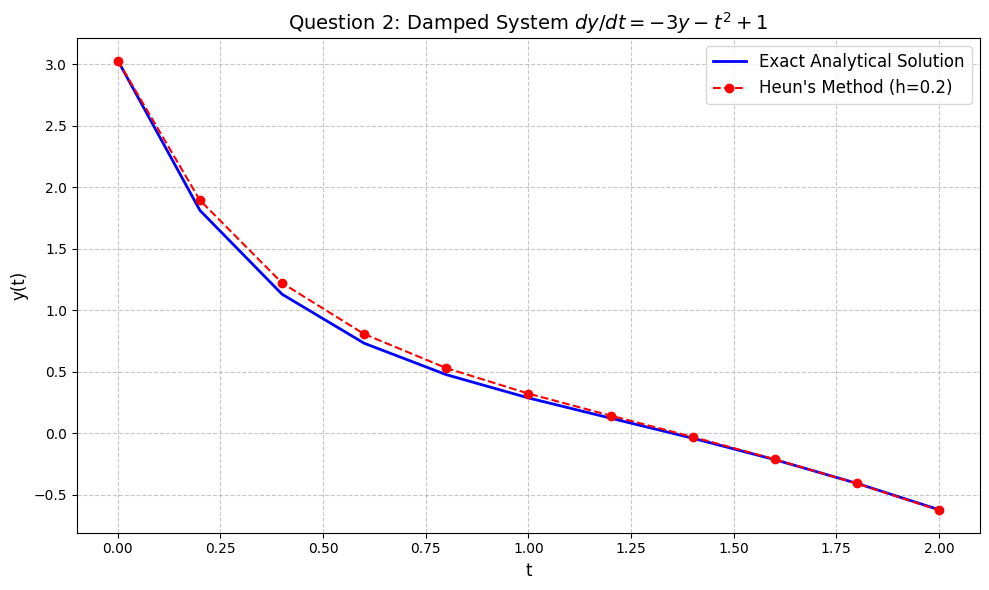

t	Heun (h=0.2)	Exact		Abs Error
------------------------------------------------
0.0	3.029000	3.029000	0.000000
0.2	1.892820	1.810436	0.082384
0.4	1.220236	1.129045	0.091191
0.6	0.805337	0.730428	0.074909
0.8	0.528695	0.474969	0.053726
1.0	0.321043	0.286045	0.034998
1.2	0.142205	0.121606	0.020600
1.4	-0.031121	-0.041429	0.010308
1.6	-0.212450	-0.215724	0.003274
1.8	-0.409621	-0.408231	0.001390
2.0	-0.627180	-0.622764	0.004416


In [32]:
# Parameters for Q2
K = D  # K = 3
h_q2 = 0.2
t_q2 = np.arange(t_start, t_end + 1e-10, h_q2)

# ODE derivative function for Q2
def f_q2(t, y):
    return -K * y - t**2 + 1

# Analytical exact solution for Q2
def exact_sol_q2(t):
    C = Y0 - (7.0 / 27.0)
    return -(1.0/3.0)*(t**2) + (2.0/9.0)*t + (7.0/27.0) + C * np.exp(-3*t)

# Compute Numerical & Exact
heun_q2 = heun_solver(f_q2, Y0, t_q2, h_q2)
exact_q2 = exact_sol_q2(t_q2)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(t_q2, exact_q2, 'b-', label='Exact Analytical Solution', linewidth=2)
plt.plot(t_q2, heun_q2, 'ro--', label="Heun's Method (h=0.2)", markersize=6)
plt.title('Question 2: Damped System $dy/dt = -3y - t^2 + 1$', fontsize=14)
plt.xlabel('t', fontsize=12)
plt.ylabel('y(t)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Print Table Comparison
print("t\tHeun (h=0.2)\tExact\t\tAbs Error")
print("-" * 48)
for i in range(len(t_q2)):
    err = abs(exact_q2[i] - heun_q2[i])
    print(f"{t_q2[i]:.1f}\t{heun_q2[i]:.6f}\t{exact_q2[i]:.6f}\t{err:.6f}")

### Question 2 Numerical Stability & Error Profile Analysis

1. **Numerical Stability Analysis:**
   - For a linear differential equation $y' = \lambda y$ with $\lambda = -K = -3$, the stability function for Heun's method is:
     $$G(z) = 1 + z + \frac{z^2}{2}, \quad \text{where } z = \lambda h = -3(0.2) = -0.6$$
   - Calculating stability multiplier:
     $$G(-0.6) = 1 + (-0.6) + \frac{(-0.6)^2}{2} = 1 - 0.6 + 0.18 = 0.58$$
   - Since $|G(-0.6)| = 0.58 < 1$, the choice of step size $h = 0.2$ is **absolutely stable**. Numerical errors will decay exponentially over time rather than grow uncontrollably.

2. **Damping Effect ($K=3$) vs. Un-damped System:**
   - **Un-damped System (Q1):** $\lambda = +1 > 0$. The homogeneous transient term grows exponentially ($e^t$). As a result, truncation errors accumulated in early steps are amplified by $e^t$, leading to larger absolute errors as $t$ increases.
   - **Damped System (Q2):** $\lambda = -3 < 0$. The transient component decays rapidly ($e^{-3t}$). The dynamic trajectory quickly converges to the steady polynomial state $y(t) \approx -\frac{1}{3}t^2 + \frac{2}{9}t + \frac{7}{27}$. The negative feedback dampens prior numerical errors, constraining the absolute error profile over time.
   